<div style="background: linear-gradient(135deg, #F43F5E 0%, #F59E0B 100%); padding: 24px; border-radius: 12px; color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);">
    <h1 style="margin: 0 0 8px 0; color: #ffffff; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Cleaning Guidelines</h1>
    <div style="background: rgba(255, 255, 255, 0.2); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Goal:</strong> Find trends
    </div>
</div>

In [2]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

all_dfs = pd.read_pickle('all_clean_dfs3.pkl')

df = all_dfs['df']
clean_df = all_dfs['clean_df']
clean_df2 = all_dfs['clean_df2']
clean_df3 = all_dfs['clean_df3']

In [5]:
print(clean_df.columns.tolist())

['Building #', 'Grade', 'Subject', 'Teacher Years of Experience', 'Test Score Year 1', 'Test Score Year 2']


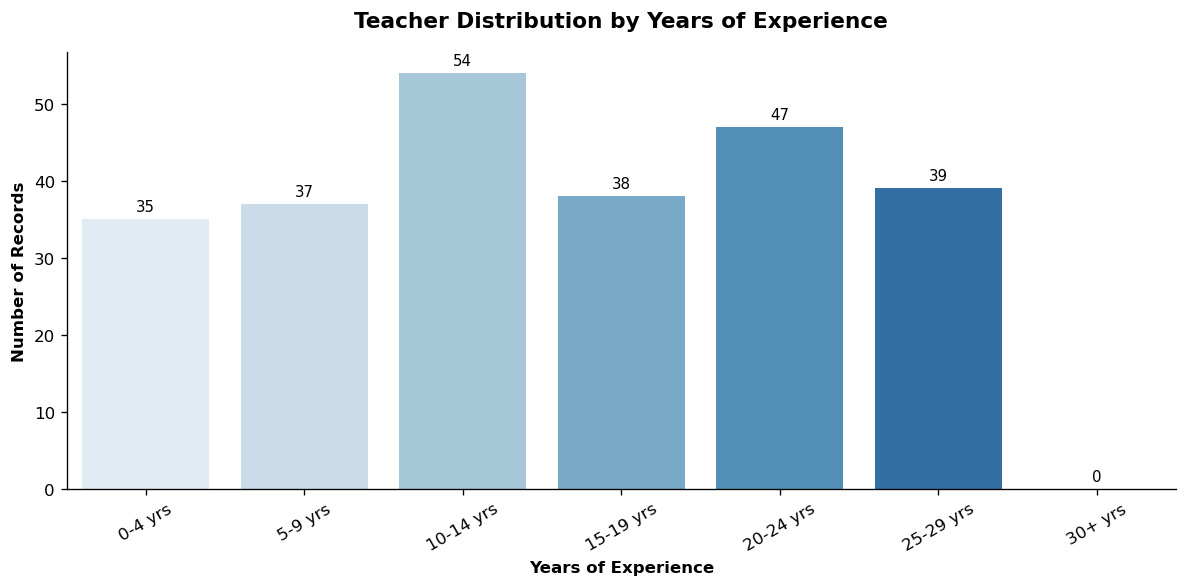

In [11]:
#bins&labels
bins = [-1, 5, 10, 15, 20, 25, 30, float("inf")]
labels = [
    "0-4 yrs",
    "5-9 yrs",
    "10-14 yrs",
    "15-19 yrs",
    "20-24 yrs",
    "25-29 yrs",
    "30+ yrs",
]

clean_df["Experience_Bin"] = pd.cut(
    clean_df["Teacher Years of Experience"], bins=bins, labels=labels
)

exp_counts = (
    clean_df.groupby("Experience_Bin", observed=False)
    .size()
    .reset_index(name="Teacher_Count")
)

#Format & plot
plt.figure(figsize=(10, 5), dpi=120)

ax = sns.barplot(
    data=exp_counts,
    x="Experience_Bin",
    y="Teacher_Count",
    hue="Experience_Bin",
    palette="Blues", 
    legend=False,
)

# Top of bars labelling
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

# Chart shape & labels
sns.despine(top=True, right=True)
plt.title(
    "Teacher Distribution by Years of Experience", fontsize=13, fontweight="bold", pad=15
)
plt.xlabel("Years of Experience", fontsize=10, fontweight="bold")
plt.ylabel("Number of Records", fontsize=10, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

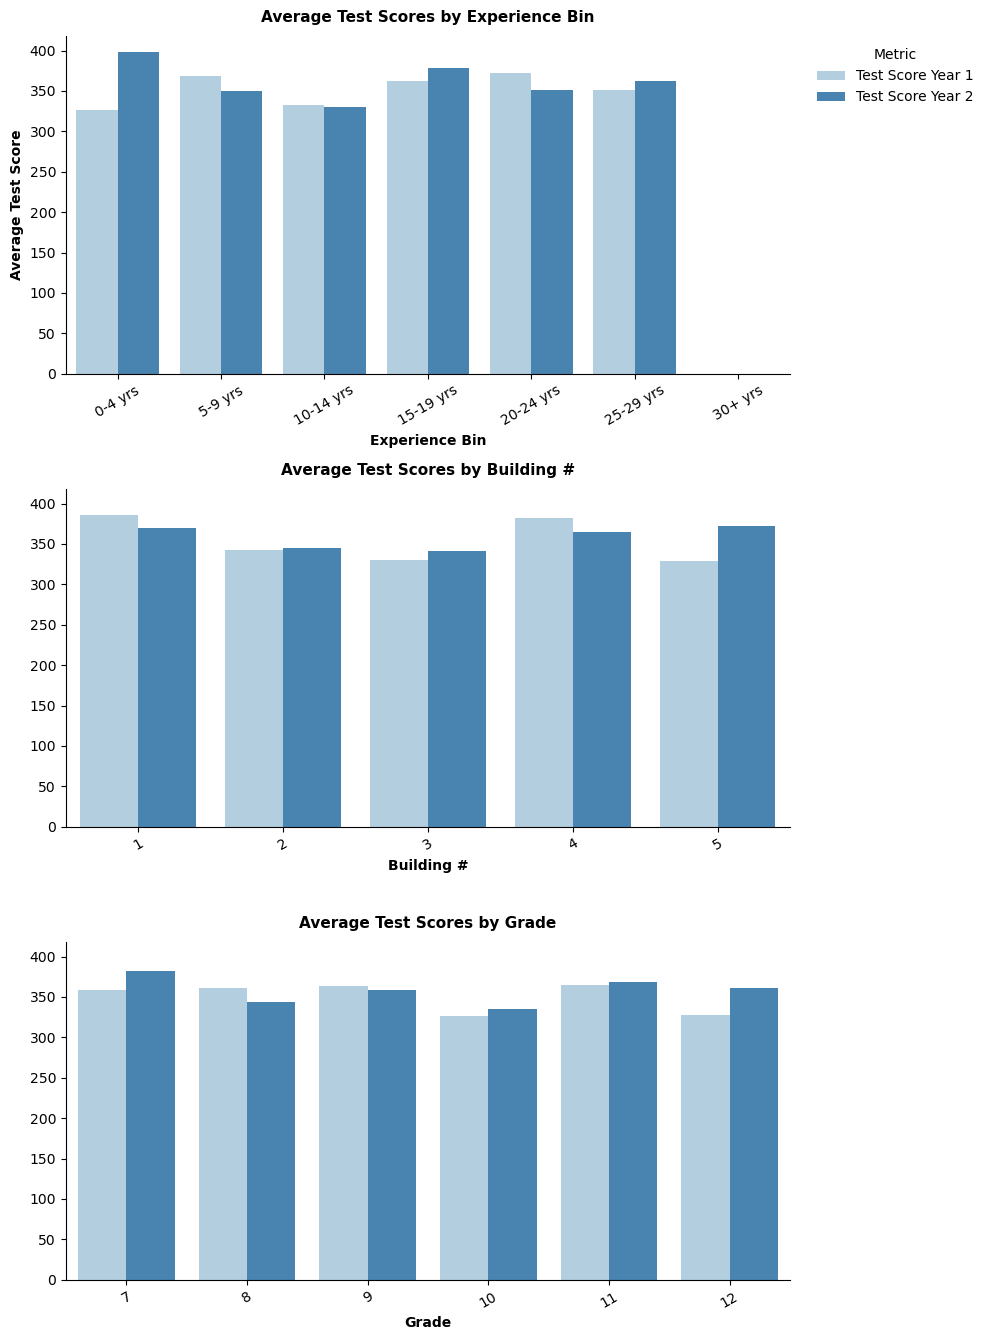

In [16]:
# variables
group_vars = ["Experience_Bin", "Building #", "Grade"]
active_vars = [var for var in group_vars if var in clean_df.columns]

#subplots
fig, axes = plt.subplots(
    len(active_vars), 1, figsize=(10, 4.5 * len(active_vars)), sharey=True
)

if len(active_vars) == 1:
    axes = [axes]

for i, var in enumerate(active_vars):
    # Group by category
    summary_df = (
        clean_df.groupby(var, observed=False)[["Test Score Year 1", "Test Score Year 2"]]
        .mean()
        .reset_index()
    )
    

    melted_df = summary_df.melt(
        id_vars=[var], 
        value_vars=["Test Score Year 1", "Test Score Year 2"],
        var_name="Test_Year", 
        value_name="Average_Score"
    )

    # Grouped bar chart - Year 1 and Year 2
    sns.barplot(
        data=melted_df,
        x=var,
        y="Average_Score",
        hue="Test_Year",
        palette="Blues",
        ax=axes[i],
        legend=(i == 0) # Only show legend on first
    )

    # Styling
    axes[i].set_title(
        f"Average Test Scores by {var.replace('_', ' ').title()}",
        fontsize=11,
        fontweight="bold",
        pad=10,
    )
    axes[i].set_xlabel(
        var.replace("_", " ").title(), fontsize=10, fontweight="bold"
    )
    axes[i].set_ylabel("Average Test Score" if i == 0 else "", fontsize=10, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=30)
    
    sns.despine(ax=axes[i], top=True, right=True)
    # Legend cleanup - move to the right
    if i == 0:
        axes[i].legend(
            title="Metric", 
            frameon=False, 
            loc="upper left",
            bbox_to_anchor=(1.02, 1)  
        )

plt.tight_layout()
plt.show()

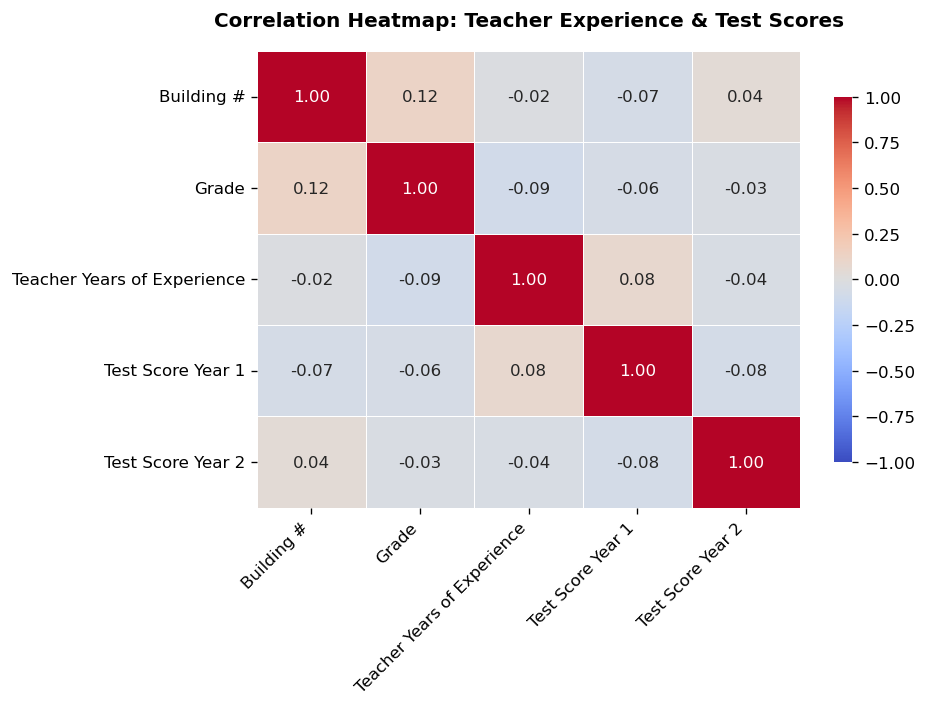

In [17]:
#Select only numerical columns
numeric_cols = clean_df.select_dtypes(include=['number']).columns
corr_matrix = clean_df[numeric_cols].corr()

plt.figure(figsize=(8, 6), dpi=120)

sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the actual correlation numbers inside cells
    fmt=".2f",           # Format numbers to 2 decimal places
    cmap="coolwarm",     # Diverging color map (good for negative/positive correlations)
    vmin=-1, vmax=1,     # Standard correlation range bounds
    linewidths=0.5,      # Add subtle grid lines between cells
    cbar_kws={"shrink": .8}
)

#styling & Layout
plt.title("Correlation Heatmap: Teacher Experience & Test Scores", fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()